In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.stem import PorterStemmer, LancasterStemmer
import nltk
from SOM import SOM
from help_functions import visualize_u_matrix, visualize_label_matrix, visualize_u_matrix_extended


In [2]:
df = pd.read_csv('../data/Time_magazine.csv')
y = df['file'].to_numpy()
X = df.drop(['file'], axis=1).to_numpy()

In [3]:
stemmer = PorterStemmer()

def english_tokenizer(text):  
    tokens = nltk.word_tokenize(text)
    stems = [stemmer.stem(t) for t in tokens if t.isalpha()]
    return stems

# TF-IDF transformation on the text with filtering on high and low frequency terms
tfidf_vectorizer = TfidfVectorizer(
    tokenizer = english_tokenizer,
    token_pattern = None,
    max_df=0.9,  
    min_df=0.01, 
)

In [4]:
X_sparse = tfidf_vectorizer.fit_transform(X.ravel())
X_tfidf = X_sparse.toarray()

In [5]:
X_tfidf.shape

(420, 3940)

In [6]:
som = SOM(number_of_rows = 10,
          number_of_cols = 10,
          input_dim = X_tfidf.shape[1])

In [7]:
som.train_online(X_tfidf, y, 500)

Epoch 0/500 complete. Sigma: 4.9542, Lr: 0.4954, QE: 1.0083, TE: 0.1000, Purity: 0.0476
Epoch 10/500 complete. Sigma: 4.7312, Lr: 0.4731, QE: 1.0030, TE: 0.1262, Purity: 0.0690
Epoch 20/500 complete. Sigma: 4.5182, Lr: 0.4518, QE: 1.0019, TE: 0.1000, Purity: 0.0738
Epoch 30/500 complete. Sigma: 4.3149, Lr: 0.4315, QE: 0.9963, TE: 0.2167, Purity: 0.0738
Epoch 40/500 complete. Sigma: 4.1207, Lr: 0.4121, QE: 0.9916, TE: 0.0786, Purity: 0.0810
Epoch 50/500 complete. Sigma: 3.9352, Lr: 0.3935, QE: 0.9860, TE: 0.0857, Purity: 0.0762
Epoch 60/500 complete. Sigma: 3.7581, Lr: 0.3758, QE: 0.9743, TE: 0.0881, Purity: 0.0857
Epoch 70/500 complete. Sigma: 3.5890, Lr: 0.3589, QE: 0.9806, TE: 0.1357, Purity: 0.0905
Epoch 80/500 complete. Sigma: 3.4274, Lr: 0.3427, QE: 0.9714, TE: 0.0595, Purity: 0.1238
Epoch 90/500 complete. Sigma: 3.2732, Lr: 0.3273, QE: 0.9703, TE: 0.1262, Purity: 0.1167
Epoch 100/500 complete. Sigma: 3.1259, Lr: 0.3126, QE: 0.9708, TE: 0.0667, Purity: 0.1500
Epoch 110/500 complet

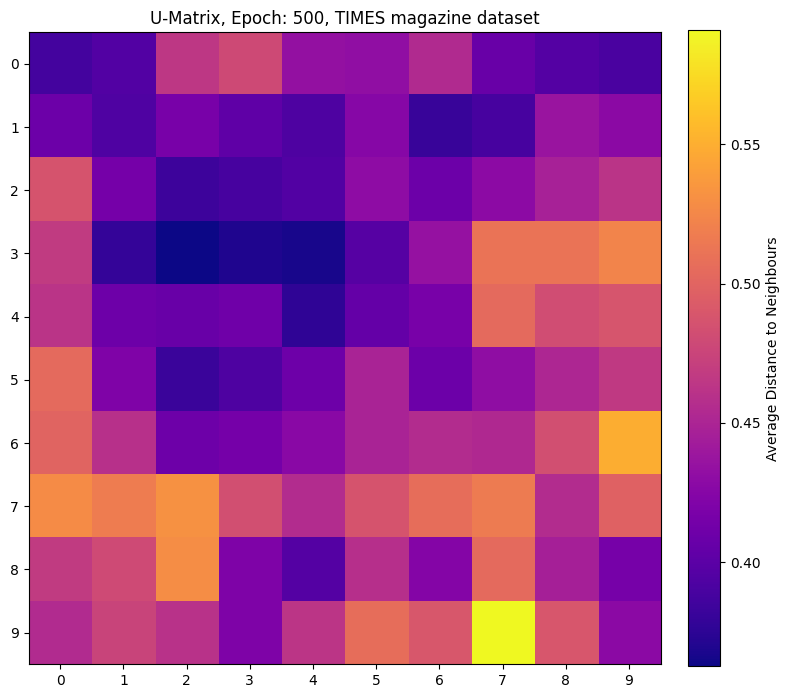

In [8]:
visualize_u_matrix(som, 500, "TIMES magazine")

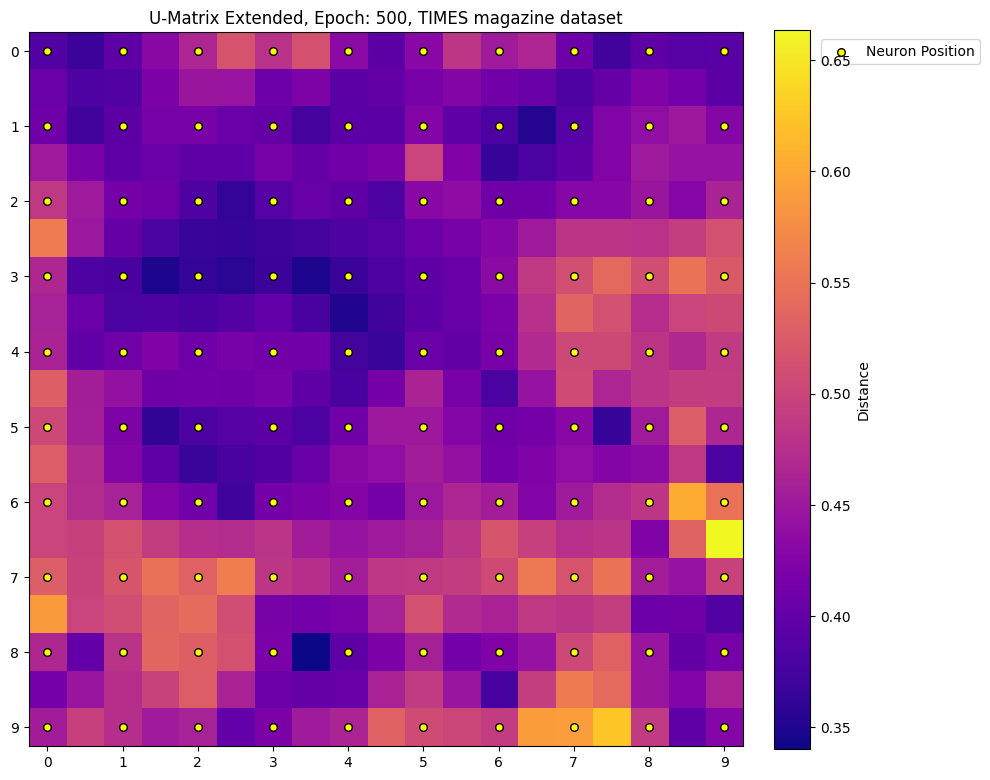

In [9]:
visualize_u_matrix_extended(som, 500, "TIMES magazine")

In [10]:
terms = tfidf_vectorizer.get_feature_names_out()

In [11]:
for i in range(som.map_rows):
    for j in range(som.map_cols):
        print(f"Node ({i},{j}):", end=" ")
        som.describe_node(X_tfidf, y, terms, (i,j), 10, True)
        print()

Node (0,0): Top 10 words: de, gaull, franc, he, charl, hi, french, as, pari, le, 
Samples: T045.html, T086.html, T102.html, T128.html, T158.html, T274.html, T323.html, T367.html, 

Node (0,1): Top 10 words: de, gaull, franc, miner, gaullist, hi, he, charl, is, strike, 
Samples: T143.html, T197.html, T292.html, T357.html, T471.html, T528.html, 

Node (0,2): Top 10 words: debr, franc, de, gaull, gaullist, he, as, is, michel, french, 
Samples: T172.html, T180.html, T261.html, T402.html, 

Node (0,3): Top 10 words: socialist, parti, coalit, peopl, hi, elect, austria, austrian, he, govern, 
Samples: T182.html, T318.html, T430.html, T523.html, T527.html, 

Node (0,4): Top 10 words: nenni, fanfani, christian, democrat, socialist, itali, moro, apertura, parti, coalit, 
Samples: T043.html, T107.html, T230.html, T247.html, T278.html, T331.html, T348.html, T485.html, T530.html, 

Node (0,5): Top 10 words: nenni, fanfani, evtushenko, christian, democrat, socialist, adenau, erhard, he, itali, 
Samp